In [1]:
import edes 
from edes.experiments import Experiment
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.circuits import dBm_to_Vp, dBm_to_W, Vp_to_dBm
from edes.modules.trap_drive.utils import beep
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
from edes.experiments.sequences import base as sequences
from edes.experiments.sequences import calibration

from edes.experiments.devices.base import Instrument
from edes.modules.variable_attenuator import var_attn_utils
from edes.utils.file_handling import load_latest_data
from edes.utils.utils import beep_jupyter, U2_to_MHz
from typing import TYPE_CHECKING

# 1. This code block ONLY runs in your IDE for auto-complete
# It is completely ignored when the code actually runs
if TYPE_CHECKING:
    from edes.experiments.devices.base import *
big_plt_font()

In [2]:
exp = Experiment('3layer_trapping_081726')

>>> ERROR connecting to RigolDG4062 at TCPIP::192.168.169.104::INSTR: VI_ERROR_RSRC_NFOUND (-1073807343): Insufficient location information or the requested device or resource is not present in the system.
>>> ERROR initializing device AWG: 'RigolDG4062' object has no attribute 'instrument'
>>> Connected to Agilent Technologies,34461A,MY53200916,A.01.08-02.22-00.08-00.35-01-01

>>> Connected to ARTIQ Zotino.
>>> ERROR initializing device DAC: No module named 'artiq'
>>> Connected to RIGOL TECHNOLOGIES,DP832A,DP8B260200018,00.01.19

>>> ERROR connecting to Keithley2100 at USB0::1510::8448::1243106::0::INSTR: No device found.
>>> Connected to Siglent Technologies,SPD3303X-E,SPD3XJEQ6R3773,1.01.01.02.07R2,V3.0

>>> Connected to Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10

>>> ERROR initializing device Valon: ('VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.', 'setting Valon_frequency to 1463230000')


In [7]:
exp.Valon.set_frequency(1.482e9)
exp.Valon.set_power(0)
exp.Valon.output_off()

In [3]:
exp.Agilent.measure_V()

-0.35607592

In [4]:
exp.Keithley.measure_V()

-0.411075232

In [5]:
ch_fixed = 'pos' 
ch_sweep = 'neg'
V_fixed = 500
V_stop = 600
V_start = 100
V_step = 30

t_PSU_settle = 2
t_meas_delay = 0.2 
N_avg = 4
R_tip = 200e6
R_ring = 100e6
I_max = 30e-9
exp.FEtip_PSU.ramp_up_ch(ch_fixed, V_fixed)
exp.FEtip_PSU.select_ch(ch_sweep)
all_I_tip = [] 
all_I_ring = []

num_steps = int(np.around((V_stop - V_start) / V_step)) + 1

# 2. Create an array of clean integers [0, 1, 2, ..., num_steps - 1]
# 3. Multiply by the step and add the start value
exp.FEtip_PSU.set_voltage(V_start) 
time.sleep(t_PSU_settle*7) 
all_V = V_start + np.arange(num_steps) * V_step

for V in tqdm(all_V): 
    exp.FEtip_PSU.set_voltage(V) 
    time.sleep(t_PSU_settle) 
    I_loc_tip = []
    I_loc_ring = []

    for _ in range(N_avg):
        I_tip = exp.Agilent.measure_V()/R_tip
        I_loc_tip.append(I_tip)
        I_ring = exp.Keithley.measure_V()/R_ring
        I_loc_ring.append(I_ring)
        time.sleep(t_meas_delay) 
    all_I_tip.append(I_loc_tip) 
    all_I_ring.append(I_loc_ring)
    if I_tip >= I_max: 
        print(f">>> Warning: Current {I} exceeds maximum allowed {I_max}. Stopping sweep.")
        break
exp.FEtip_PSU.ramp_down(0)
exp.FEtip_PSU.ramp_down_ch(ch_fixed, 0)

100%|███████████████████████████████████████████| 18/18 [01:43<00:00,  5.77s/it]


Text(0.5, 1.0, 'I_tip vs sweep Voltage')

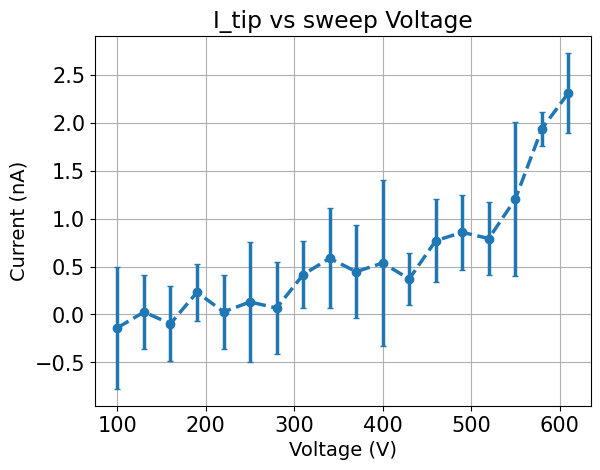

In [6]:
I_mean_tip = np.mean(all_I_tip, axis=1)
I_std_tip = np.std(all_I_tip, axis=1)
plot_errbar(all_V, I_mean_tip*1e9, yerr=I_std_tip*1e9, fmt='.--', xlabel='Voltage (V)', ylabel='Current (nA)')
plt.title('I_tip vs sweep Voltage')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


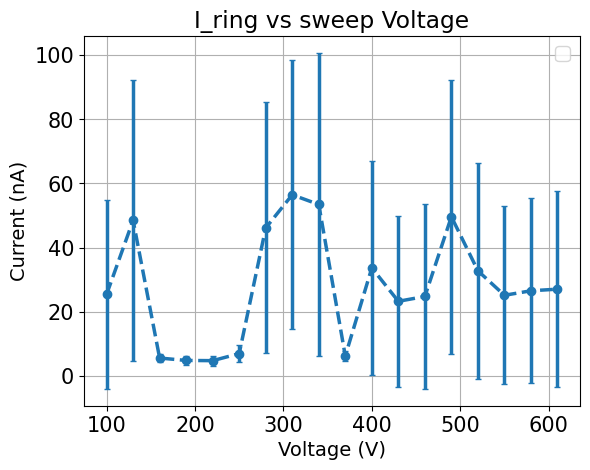

In [7]:
I_mean_ring = np.mean(all_I_ring, axis=1)
I_std_ring = np.std(all_I_ring, axis=1)
plot_errbar(all_V, I_mean_ring*1e9, yerr=I_std_ring*1e9, fmt='.--', xlabel='Voltage (V)', ylabel='Current (nA)')
plt.title('I_ring vs sweep Voltage')
plt.legend()
plt.grid(True)
plt.show()